<a href="https://colab.research.google.com/github/swethanjali24/Mini_Project_on_IPL_Data_Analysis/blob/main/Mini_Project_on_IPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project: IPL - Data Analysis EDA**

**Problem Statement-**
*Conduct a comprehensive analysis of the Indian Premier League (IPL) dataset. The analysis should cover various aspects such as the number of matches played in each season, runs scored, toss-related statistics, team performance, player statistics, and more.*


**Brief about IPL**-
*The Indian Premier League (IPL) a professional Twenty20 cricket league in India usually contested between March and May of every year by eight teams representing eight different cities or states in India. The league was founded by the Board of Control for Cricket in India (BCCI) in 2007. The IPL is the most-attended cricket league in the world and the brand value of the IPL in 2019 was 475 billion (US$6.7 billion)*


# **Importing important libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **# Importing the datasets**

In [ ]:
matches_df=pd.read_csv('/content/drive/MyDrive/Mini_Projects/EDA/IPL Matches 2008-2020.csv')
balls_df=pd.read_csv('/content/drive/MyDrive/Mini_Projects/EDA/IPL Ball-by-Ball 2008-2020.csv')


# **Data Preprocessing**

In [ ]:
# Knowing the data
matches_df.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


In [ ]:

'''
Few column headers are well understood,whereas for few we have to dig deeper to understand like the 'neutral venue'
Hence we will go one by one for such columns
'''

"\nFew column headers are well understood,whereas for few we have to dig deeper to understand like the 'neutral venue'\nHence we will go one by one for such columns\n"

In [ ]:
# Total columns
print('Total columns in matches_df:\n',matches_df.columns)

Total columns in matches_df:
 Index(['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2'],
      dtype='object')


In [ ]:
# Getting to know the data
neutral_matches=matches_df[matches_df['neutral_venue']==1].groupby('venue')['id'].count().sort_values(ascending=False)
print(neutral_matches)
print('Total no.of matches played in neutral venue:',sum(neutral_matches))
matches_df['method'].value_counts()

venue
Kingsmead                              15
SuperSport Park                        12
New Wanderers Stadium                   8
St George's Park                        7
Sheikh Zayed Stadium                    7
Dubai International Cricket Stadium     7
Newlands                                7
Sharjah Cricket Stadium                 6
Buffalo Park                            3
De Beers Diamond Oval                   3
OUTsurance Oval                         2
Name: id, dtype: int64
Total no.of matches played in neutral venue: 77


,count
method,
D/L,19


In [ ]:
'''
Data present in matches_df

1.id-unique id for each match
2.city-city where match was played
3.date-date on which match was played
4.player of the match-player who won the man of the match award
5.venue-venue where match was played
6.neutral_venue-Matches played in neutral venues are marked with 1, i.e played outside India(Total 11 different venues outside india, and a total of 77 matches
were played at neutral venue)
7.Team1 and Team2 are the teams playing in the match
8.Toss winner-team who won the toss
9.Toss decision-Bat/Bowl-what did the team choose
10.winner-Team which won the match
11.result-result of the match won by no. of runs/wickets
12.result_margin-by what margin the team won
13.Eliminator-Whether the match is an eliminator
14.method-By which method the match was won-Normal or D/L method(19 matches are won through D/L method)
15.Umpire1 and Umpire2-Umpires who umpired the match
'''


'\nData present in matches_df\n\n1.id-unique id for each match\n2.city-city where match was played\n3.date-date on which match was played\n4.player of the match-player who won the man of the match award\n5.venue-venue where match was played\n6.neutral_venue-Matches played in neutral venues are marked with 1, i.e played outside India(Total 11 different venues outside india, and a total of 77 matches\nwere played at neutral venue)\n7.Team1 and Team2 are the teams playing in the match\n8.Toss winner-team who won the toss\n9.Toss decision-Bat/Bowl-what did the team choose\n10.winner-Team which won the match\n11.result-result of the match won by no. of runs/wickets\n12.result_margin-by what margin the team won\n13.Eliminator-Whether the match is an eliminator\n14.method-By which method the match was won-Normal or D/L method(19 matches are won through D/L method)\n15.Umpire1 and Umpire2-Umpires who umpired the match\n'

In [ ]:
# Getting to know the data for the dataset,'balls_df'
balls_df.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [ ]:
balls_df['inning'].value_counts()

,count
inning,
1,100191
2,93277


In [ ]:
balls_df['dismissal_kind'].value_counts()# Types of dismissal

,count
dismissal_kind,
caught,5743
bowled,1700
run out,893
lbw,571
stumped,294
caught and bowled,269
hit wicket,12
retired hurt,11
obstructing the field,2


In [ ]:
balls_df['fielder'].value_counts()# who was the fielder involved in getting that wicket

,count
fielder,
MS Dhoni,164
KD Karthik,156
RV Uthappa,123
AB de Villiers,117
SK Raina,105
...,...
"BJ Rohrer,KM Jadhav",1
K Upadhyay,1
"L Balaji,MS Bisla",1


In [ ]:
balls_df['non_boundary'].value_counts()

,count
non_boundary,
0,193452
1,16


In [ ]:
# Check for inconsistencies
check = balls_df[(balls_df['batsman_runs'].isin([4, 6])) & (balls_df['non_boundary'] == 1)]
print(check)

             id  inning  over  ball        batsman       non_striker  \
7505     336014       1    19     6      LR Shukla         DJ Hussey   
23749    392226       2     1     3      SM Katich           S Sohal   
47927    501225       2     4     4       R Dravid         SR Watson   
54183    501252       2     5     1       CH Gayle        TM Dilshan   
55334    501257       1     2     3    PC Valthaty      AC Gilchrist   
59111    548308       2    11     3   JEC Franklin          SA Yadav   
74924    548376       2     7     1        V Kohli    AB de Villiers   
82699    598024       1     4     2   SR Tendulkar        KD Karthik   
91617    598061       2    10     3      YK Pathan  RN ten Doeschate   
123397   980909       2     9     7      RG Sharma         HH Pandya   
132655   980987       1     3     1        V Kohli          CH Gayle   
137361  1082594       2    12     4     GJ Maxwell         DA Miller   
138887  1082601       1    18     6      MM Sharma          VR A

In [ ]:
'''
Here non-boundary coulmn is slight confusing as non-boundary=1 is giving batsman_runs as 4 or 6.

'''

'\nHere non-boundary coulmn is slight confusing as non-boundary=1 is giving batsman_runs as 4 or 6.\n\n'

In [ ]:
'''
Data present in balls_df

1.id- unique id for each match
2.innings-inning number 1 or 2
3.overs-over number
4.ball-ball number
5.batsman-batsman name
6.non_striker-non striker name
7.Bowler-bowler name
8.Batsman_runs-Runs scored by batsman alone with his bat in that particular ball
9.Extra_runs-runs gained by extras like wide, no-ball,byes in that particular ball
10.Total_runs-total runs scored in that particular ball
11.non_boundary-
12.is_wicket-whether the batsman got out in that particular ball
13.dismissal_kind->If the batsman got out in that particular ball,in what way did he get out
14.player_dismissed->Who was the player that got dimissed in that particular ball
15.fielder-Who was the fielder involved in getting the wicket in that particular ball
16.Extra_types-what were the types of extras occurred during that particular ball
17.Batting_team-which team was batting in that particular ball
18.Bowling_team-which team was bowling in that particular ball
'''

'\nData present in balls_df\n\n1.id- unique id for each match\n2.innings-inning number 1 or 2\n3.overs-over number\n4.ball-ball number\n5.batsman-batsman name\n6.non_striker-non striker name\n7.Bowler-bowler name\n8.Batsman_runs-Runs scored by batsman alone with his bat in that particular ball\n9.Extra_runs-runs gained by extras like wide, no-ball,byes in that particular ball\n10.Total_runs-total runs scored in that particular ball\n11.non_boundary-\n12.is_wicket-whether the batsman got out in that particular ball\n13.dismissal_kind->If the batsman got out in that particular ball,in what way did he get out\n14.player_dismissed->Who was the player that got dimissed in that particular ball\n15.fielder-Who was the fielder involved in getting the wicket in that particular ball\n16.Extra_types-what were the types of extras occurred during that particular ball\n17.Batting_team-which team was batting in that particular ball\n18.Bowling_team-which team was bowling in that particular ball\n'

# **EDA**

In [ ]:
# Cleaning the datasets
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    object 
dtypes: float64(1), i

In [ ]:
# All the Columns in matches dataframe are appropriate,except 'Date' column.
matches_df['date']=pd.to_datetime(matches_df['date'])
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               816 non-null    int64         
 1   city             803 non-null    object        
 2   date             816 non-null    datetime64[ns]
 3   player_of_match  812 non-null    object        
 4   venue            816 non-null    object        
 5   neutral_venue    816 non-null    int64         
 6   team1            816 non-null    object        
 7   team2            816 non-null    object        
 8   toss_winner      816 non-null    object        
 9   toss_decision    816 non-null    object        
 10  winner           812 non-null    object        
 11  result           812 non-null    object        
 12  result_margin    799 non-null    float64       
 13  eliminator       812 non-null    object        
 14  method           19 non-null     object   

In [ ]:
balls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193468 entries, 0 to 193467
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                193468 non-null  int64 
 1   inning            193468 non-null  int64 
 2   over              193468 non-null  int64 
 3   ball              193468 non-null  int64 
 4   batsman           193468 non-null  object
 5   non_striker       193468 non-null  object
 6   bowler            193468 non-null  object
 7   batsman_runs      193468 non-null  int64 
 8   extra_runs        193468 non-null  int64 
 9   total_runs        193468 non-null  int64 
 10  non_boundary      193468 non-null  int64 
 11  is_wicket         193468 non-null  int64 
 12  dismissal_kind    9495 non-null    object
 13  player_dismissed  9495 non-null    object
 14  fielder           6784 non-null    object
 15  extras_type       10233 non-null   object
 16  batting_team      193468 non-null  obj

In [ ]:
# All the datatypes in balls dataframe are appropriate

In [ ]:
matches_df.isnull().sum()

,0
id,0
city,13
date,0
player_of_match,4
venue,0
neutral_venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0


In [ ]:
# there are null values which ought to be filled with appropriate values before solving the problem.

In [ ]:
# Filling the city null values.(13 null values)

In [ ]:
matches_df[matches_df['city'].isnull()]

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
399,729281,NaN,2014-04-17,YS Chahal,Sharjah Cricket Stadium,1,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,N,NaN,Aleem Dar,S Ravi
402,729287,NaN,2014-04-19,PA Patel,Dubai International Cricket Stadium,1,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,N,NaN,Aleem Dar,AK Chaudhary
403,729289,NaN,2014-04-19,JP Duminy,Dubai International Cricket Stadium,1,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,Delhi Daredevils,wickets,4.0,N,NaN,Aleem Dar,VA Kulkarni
404,729291,NaN,2014-04-20,GJ Maxwell,Sharjah Cricket Stadium,1,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,7.0,N,NaN,BF Bowden,M Erasmus
406,729295,NaN,2014-04-22,GJ Maxwell,Sharjah Cricket Stadium,1,Kings XI Punjab,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kings XI Punjab,runs,72.0,N,NaN,M Erasmus,S Ravi
407,729297,NaN,2014-04-23,RA Jadeja,Dubai International Cricket Stadium,1,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Chennai Super Kings,runs,7.0,N,NaN,HDPK Dharmasena,RK Illingworth
408,729299,NaN,2014-04-24,CA Lynn,Sharjah Cricket Stadium,1,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,2.0,N,NaN,Aleem Dar,VA Kulkarni
409,729301,NaN,2014-04-25,AJ Finch,Dubai International Cricket Stadium,1,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,4.0,N,NaN,M Erasmus,S Ravi
410,729303,NaN,2014-04-25,MM Sharma,Dubai International Cricket Stadium,1,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Chennai Super Kings,wickets,7.0,N,NaN,BF Bowden,M Erasmus
413,729309,NaN,2014-04-27,M Vijay,Sharjah Cricket Stadium,1,Delhi Daredevils,Mumbai Indians,Mumbai Indians,bat,Delhi Daredevils,wickets,6.0,N,NaN,Aleem Dar,VA Kulkarni


In [ ]:
# From the above it can be seen that the city name can be found from the venue name

In [ ]:
matches_df[matches_df['city'].isnull()]['venue'].unique()

array(['Sharjah Cricket Stadium', 'Dubai International Cricket Stadium'],
      dtype=object)

In [ ]:
matches_df[matches_df['venue']=='Sharjah Cricket Stadium']['city'].unique()

array([nan, 'Sharjah'], dtype=object)

In [ ]:
venue_city_map=matches_df.dropna(subset=['city'])[['venue','city']].drop_duplicates().set_index('venue')['city'].to_dict()
# Created a dictionary with venue and city as key-value pairs.

In [ ]:
matches_df['city']=matches_df['city'].fillna(matches_df['venue'].map(venue_city_map))
# Filled the NAN values in 'city' column with values in venue_city_map


In [ ]:
matches_df.isnull().sum()

,0
id,0
city,0
date,0
player_of_match,4
venue,0
neutral_venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0


In [ ]:
'''
Checking for null values.

'''


'\nChecking for null values.\n\n'

In [ ]:
matches_df[matches_df['player_of_match'].isnull()]
# Can't fill the null values in 'player of the match' column as we dont have any data,similarly with 'winner','result' and 'eliminator' columns


,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
241,501265,Delhi,2011-05-21,NaN,Feroz Shah Kotla,0,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,NaN,NaN,NaN,NaN,SS Hazare,RJ Tucker
486,829763,Bangalore,2015-04-29,NaN,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,NaN,NaN,NaN,NaN,JD Cloete,PG Pathak
511,829813,Bangalore,2015-05-17,NaN,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,NaN,NaN,NaN,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,Bengaluru,2019-04-30,NaN,M.Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,NaN,NaN,NaN,NaN,UV Gandhe,NJ Llong


In [ ]:
matches_df[matches_df['result_margin'].isnull()]
# No need to worry about this as result margin is not available for matches which turned out to be tie.Winner may be present because of Super Over being played later.


,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
66,392190,Cape Town,2009-04-23,YK Pathan,Newlands,1,Kolkata Knight Riders,Rajasthan Royals,Kolkata Knight Riders,field,Rajasthan Royals,tie,NaN,Y,NaN,MR Benson,M Erasmus
130,419121,Chennai,2010-03-21,J Theron,"MA Chidambaram Stadium, Chepauk",0,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,Kings XI Punjab,tie,NaN,Y,NaN,K Hariharan,DJ Harper
241,501265,Delhi,2011-05-21,NaN,Feroz Shah Kotla,0,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,NaN,NaN,NaN,NaN,SS Hazare,RJ Tucker
328,598004,Hyderabad,2013-04-07,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",0,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Sunrisers Hyderabad,tie,NaN,Y,NaN,AK Chaudhary,S Ravi
341,598017,Bangalore,2013-04-16,V Kohli,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Royal Challengers Bangalore,tie,NaN,Y,NaN,M Erasmus,VA Kulkarni
416,729315,Abu Dhabi,2014-04-29,JP Faulkner,Sheikh Zayed Stadium,1,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,bat,Rajasthan Royals,tie,NaN,Y,NaN,Aleem Dar,AK Chaudhary
476,829741,Ahmedabad,2015-04-21,SE Marsh,"Sardar Patel Stadium, Motera",0,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,tie,NaN,Y,NaN,M Erasmus,S Ravi
486,829763,Bangalore,2015-04-29,NaN,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,NaN,NaN,NaN,NaN,JD Cloete,PG Pathak
511,829813,Bangalore,2015-05-17,NaN,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,NaN,NaN,NaN,NaN,HDPK Dharmasena,K Srinivasan
610,1082625,Rajkot,2017-04-29,KH Pandya,Saurashtra Cricket Association Stadium,0,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,Mumbai Indians,tie,NaN,Y,NaN,AK Chaudhary,CB Gaffaney


In [ ]:
matches_df[matches_df['method'].isnull()]

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,1216547,Dubai,2020-09-28,AB de Villiers,Dubai International Cricket Stadium,0,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,tie,NaN,Y,NaN,Nitin Menon,PR Reiffel
812,1237177,Dubai,2020-11-05,JJ Bumrah,Dubai International Cricket Stadium,0,Mumbai Indians,Delhi Capitals,Delhi Capitals,field,Mumbai Indians,runs,57.0,N,NaN,CB Gaffaney,Nitin Menon
813,1237178,Abu Dhabi,2020-11-06,KS Williamson,Sheikh Zayed Stadium,0,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,6.0,N,NaN,PR Reiffel,S Ravi
814,1237180,Abu Dhabi,2020-11-08,MP Stoinis,Sheikh Zayed Stadium,0,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,runs,17.0,N,NaN,PR Reiffel,S Ravi


In [ ]:
print(matches_df.shape)
matches_df['method'].value_counts()

(816, 17)


,count
method,
D/L,19


In [ ]:
'''
Here we can conclude that there are total 816 matches in which 19 are won through D/L method and the rest are won through normal method.
So the NaN in this 'method' column can be replaced with 'Normal'.
'''

"\nHere we can conclude that there are total 816 matches in which 19 are won through D/L method and the rest are won through normal method.\nSo the NaN in this 'method' column can be replaced with 'Normal'.\n"

In [ ]:
matches_df['method']=matches_df['method'].fillna('Normal')

In [ ]:
matches_df.isnull().sum()

,0
id,0
city,0
date,0
player_of_match,4
venue,0
neutral_venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0


In [ ]:
'''
The matches dataframe is cleaned to maximum extent with the data available.
'''

'\nThe matches dataframe is cleaned to maximum extent with the data available.\n'

In [ ]:
# Cleaning the balls dataset
balls_df.isnull().sum()

,0
id,0
inning,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
batsman_runs,0
extra_runs,0
total_runs,0


In [ ]:
balls_df['dismissal_kind'].value_counts()

,count
dismissal_kind,
caught,5743
bowled,1700
run out,893
lbw,571
stumped,294
caught and bowled,269
hit wicket,12
retired hurt,11
obstructing the field,2


In [ ]:
balls_df['dismissal_kind']=balls_df['dismissal_kind'].fillna('no_dissmisal')# NAN values in 'dismissal kind' column means that particular ball is not a wicket taking ball,hence can be replaced with'no_dismissal'.


In [ ]:
balls_df['player_dismissed']=balls_df['player_dismissed'].fillna('no_dismissal')# NAN values in 'player_dismissed' column means that particular ball is not a wicket taking ball,hence can be replaced with'no_dismissal'.

In [ ]:
balls_df['fielder']=balls_df['fielder'].fillna('no_fielder')# NAN values in 'fielder' column means that particular ball is not a wicket taking ball or if it is it is not 'catch out',hence can be replaced with'no_fielder'.

In [ ]:
balls_df['extras_type']=balls_df['extras_type'].fillna('no_extras')# NAN values in 'extras_type' column means that particular ball is not an extra ball,hence can be replaced with'no_extras'.

In [ ]:
balls_df[balls_df['bowling_team'].isnull()]

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
57048,501265,1,0,1,NV Ojha,DA Warner,AC Thomas,1,0,1,0,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Delhi Daredevils,NaN
57049,501265,1,0,2,DA Warner,NV Ojha,AC Thomas,0,1,1,0,0,no_dissmisal,no_dismissal,no_fielder,legbyes,Delhi Daredevils,NaN
57050,501265,1,1,1,DA Warner,NV Ojha,JP Faulkner,0,1,1,0,0,no_dissmisal,no_dismissal,no_fielder,legbyes,Delhi Daredevils,NaN
57051,501265,1,1,2,NV Ojha,DA Warner,JP Faulkner,0,0,0,0,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Delhi Daredevils,NaN
57052,501265,1,1,3,NV Ojha,DA Warner,JP Faulkner,0,0,0,0,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Delhi Daredevils,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115654,829763,1,7,3,AB de Villiers,Mandeep Singh,STR Binny,0,0,0,0,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Royal Challengers Bangalore,NaN
115655,829763,1,8,6,AB de Villiers,Mandeep Singh,SR Watson,2,0,2,0,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Royal Challengers Bangalore,NaN
115656,829763,1,9,1,Mandeep Singh,AB de Villiers,STR Binny,4,0,4,0,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Royal Challengers Bangalore,NaN
115657,829763,1,8,4,AB de Villiers,Mandeep Singh,SR Watson,0,0,0,0,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Royal Challengers Bangalore,NaN


In [ ]:
len(balls_df['id'].unique())# Total no.of matches played in that season

816

In [ ]:
match_df=matches_df[['id','team1','team2']]
match_df

,id,team1,team2
0,335982,Royal Challengers Bangalore,Kolkata Knight Riders
1,335983,Kings XI Punjab,Chennai Super Kings
2,335984,Delhi Daredevils,Rajasthan Royals
3,335985,Mumbai Indians,Royal Challengers Bangalore
4,335986,Kolkata Knight Riders,Deccan Chargers
...,...,...,...
811,1216547,Royal Challengers Bangalore,Mumbai Indians
812,1237177,Mumbai Indians,Delhi Capitals
813,1237178,Royal Challengers Bangalore,Sunrisers Hyderabad
814,1237180,Delhi Capitals,Sunrisers Hyderabad


In [ ]:
# Adding team1 and team2 columns to the balls dataframe from matched dataframe
balls_df=balls_df.merge(matches_df[['id','team1','team2']],
                        on='id',
                        how='left')

In [ ]:
matches_df.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,Normal,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,Normal,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,Normal,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,Normal,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,Normal,BF Bowden,K Hariharan


In [ ]:
# Using the mask function to fill the NAN values in bowling team
mask1=(balls_df['bowling_team'].isnull())&(balls_df['batting_team']==balls_df['team1'])
mask2=(balls_df['bowling_team'].isnull())&(balls_df['batting_team']==balls_df['team2'])

In [ ]:
balls_df.loc[mask1,'bowling_team']=balls_df.loc[mask1,'team2']
balls_df.loc[mask2,'bowling_team']=balls_df.loc[mask2,'team1']

In [ ]:
balls_df['bowling_team'].isnull().sum()

np.int64(0)

In [ ]:
'''
We have cleaned the balls_df to maximum extent.
'''

'''
Now we proceed with the questions asked in the problem statement.
'''

'\nNow we proceed with the questions asked in the problem statement.\n'

In [ ]:
# Question 1-What was the count of matches played in each season?
matches_df['season']=matches_df['date'].dt.year # Separating the year part from the date column
matches_df['season'].value_counts().sort_index(ascending=False)

,count
season,
2020,60
2019,60
2018,60
2017,59
2016,60
2015,59
2014,60
2013,76
2012,74


In [ ]:
# Question-2--->How many runs were scored in each season?
balls_df=balls_df.merge(matches_df[['id','season']],
                        on='id',
                        how='left') # Merged the season column from matches dataframe.


In [ ]:
balls_df['total_runs'].groupby(balls_df['season']).sum()

,total_runs
season,
2008,17937
2009,16320
2010,18864
2011,21154
2012,22453
2013,22541
2014,18909
2015,18332
2016,18862


In [ ]:
# Question 3-->What were the runs scored per match in different seasons?

In [ ]:
Runs_scored_per_match_per_season=balls_df.groupby(['id','season'])['total_runs'].sum()
print(Runs_scored_per_match_per_season)

id       season
335982   2008      304
335983   2008      447
335984   2008      261
335985   2008      331
335986   2008      222
                  ... 
1216547  2020      402
1237177  2020      343
1237178  2020      263
1237180  2020      361
1237181  2020      313
Name: total_runs, Length: 816, dtype: int64


In [ ]:
# Question 4-->Who has umpired the most?

In [ ]:
matches_df['umpire1'].value_counts()

,count
umpire1,
HDPK Dharmasena,78
AK Chaudhary,56
Asad Rauf,51
M Erasmus,40
Aleem Dar,38
BF Bowden,37
S Ravi,37
BR Doctrove,34
CB Gaffaney,34


In [ ]:
matches_df['umpire2'].value_counts()

,count
umpire2,
S Ravi,84
C Shamshuddin,60
SJA Taufel,54
CK Nandan,49
RJ Tucker,41
Nitin Menon,37
BNJ Oxenford,32
VA Kulkarni,31
AK Chaudhary,31


In [ ]:
umpires=pd.concat([matches_df['umpire1'],matches_df['umpire2']]).value_counts()# Added the two umpire columns
umpires.head(1)

,count
S Ravi,121


In [ ]:
# Question 5-->Which team has won the most tosses?


In [ ]:
toss_winners=matches_df['toss_winner'].value_counts().sort_values(ascending=False)
toss_winners.head(1)

,count
toss_winner,
Mumbai Indians,106


In [ ]:
# Question 6--->What does the team decide after winning the toss?

In [ ]:
Most_toss_decision=matches_df['toss_decision'].value_counts().sort_values(ascending=False)
Most_toss_decision.head(1)

,count
toss_decision,
field,496


In [ ]:
# Question 7--->How does the toss decision vary across seasons?

In [ ]:
matches_df.groupby('season')['toss_decision'].value_counts()

season  toss_decision
2008    field            32
        bat              26
2009    bat              35
        field            22
2010    bat              39
        field            21
2011    field            48
        bat              25
2012    bat              37
        field            37
2013    bat              45
        field            31
2014    field            41
        bat              19
2015    field            34
        bat              25
2016    field            49
        bat              11
2017    field            48
        bat              11
2018    field            50
        bat              10
2019    field            50
        bat              10
2020    field            33
        bat              27
Name: count, dtype: int64

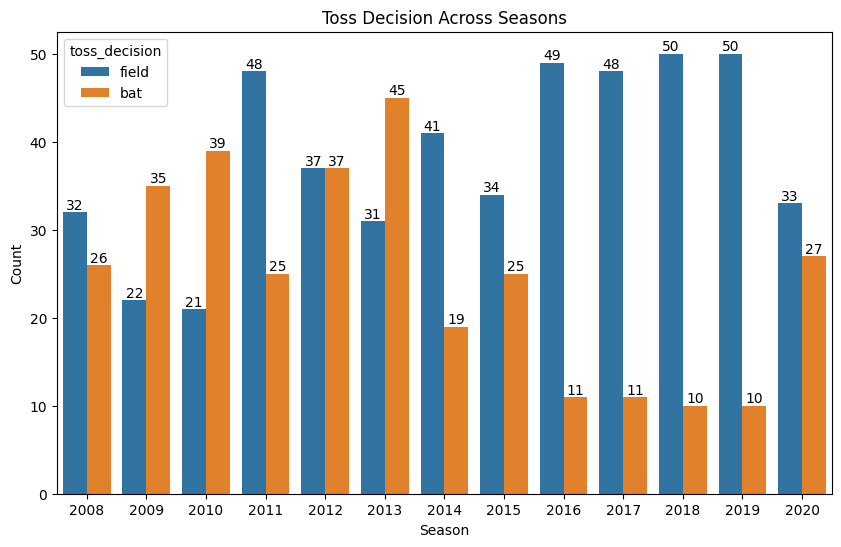

In [ ]:
plt.figure(figsize=(10,6))
ax=sns.countplot(x='season',hue='toss_decision',data=matches_df,)
plt.title('Toss Decision Across Seasons')
plt.xlabel('Season')
plt.ylabel('Count')


# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
# Question 8 -->Does winning the toss imply winning the game?

In [ ]:
toss_win_match_win=(matches_df['toss_winner']==matches_df['winner']).astype(int)
print(toss_win_match_win.mean())



0.5122549019607843


In [ ]:
# Question 9--> How many times has the chasing team won the match?

In [ ]:
# Chasing team means the team batting second
chasing_team_won=((matches_df['toss_decision']=='field')&(matches_df['winner']==matches_df['toss_winner'])|
                 (matches_df['toss_decision']=='bat')&(matches_df['winner']!=matches_df['toss_winner']))
print(chasing_team_won.sum())

448


In [ ]:
# Question 10-->Which all teams had won this tournament?

In [ ]:
final_matches = matches_df.sort_values('date').drop_duplicates('season', keep = 'last')
tournament_winners = final_matches['winner'].value_counts()
tournament_winners.index

Index(['Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Sunrisers Hyderabad'],
      dtype='object', name='winner')

In [ ]:
matches_df.columns

Index(['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2',
       'season'],
      dtype='object')

In [ ]:
#Question 11--> Which team has played the most number of matches?

In [ ]:
matches=pd.concat([matches_df['team1'],matches_df['team2']]).value_counts()
matches.head(1)

,count
Mumbai Indians,203


In [ ]:
# Question 12--->Which team has won the most number of times?

In [ ]:
most_wins = matches_df['winner'].value_counts()
most_wins.head(1).index

Index(['Mumbai Indians'], dtype='object', name='winner')

In [ ]:
# Question 13--->Which team has the highest winning percentage?

In [ ]:
total_matches=pd.concat([matches_df['team1'],matches_df['team2']]).value_counts().sort_index()
print('Total matches played by each team\n',total_matches)
print()
win_team=matches_df['winner'].value_counts().sort_index()
print('No. of times each team has won\n',win_team)
win_percentage=(win_team/total_matches)*100
print()
print('Highest win percentage team\n',win_percentage.idxmax())


Total matches played by each team
 Chennai Super Kings            178
Deccan Chargers                 75
Delhi Capitals                  33
Delhi Daredevils               161
Gujarat Lions                   30
Kings XI Punjab                190
Kochi Tuskers Kerala            14
Kolkata Knight Riders          192
Mumbai Indians                 203
Pune Warriors                   46
Rajasthan Royals               161
Rising Pune Supergiant          16
Rising Pune Supergiants         14
Royal Challengers Bangalore    195
Sunrisers Hyderabad            124
Name: count, dtype: int64

No. of times each team has won
 winner
Chennai Super Kings            106
Deccan Chargers                 29
Delhi Capitals                  19
Delhi Daredevils                67
Gujarat Lions                   13
Kings XI Punjab                 88
Kochi Tuskers Kerala             6
Kolkata Knight Riders           99
Mumbai Indians                 120
Pune Warriors                   12
Rajasthan Royals        

In [ ]:
# Question-14---->Is there any lucky venue for a particular team?

In [ ]:
lucky_venue=matches_df.groupby('winner')['venue'].value_counts().reset_index()

lucky_venue=lucky_venue.sort_values('count',ascending=False)
lucky_venue.drop_duplicates('winner',keep='first',inplace=True)
lucky_venue

,winner,venue,count
116,Kolkata Knight Riders,Eden Gardens,45
138,Mumbai Indians,Wankhede Stadium,42
0,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk",40
171,Rajasthan Royals,Sawai Mansingh Stadium,32
230,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",30
203,Royal Challengers Bangalore,M Chinnaswamy Stadium,29
51,Delhi Daredevils,Feroz Shah Kotla,27
86,Kings XI Punjab,"Punjab Cricket Association Stadium, Mohali",18
194,Rising Pune Supergiant,Maharashtra Cricket Association Stadium,5
163,Pune Warriors,Subrata Roy Sahara Stadium,4


In [ ]:
# Question 15--->Innings wise comparison between teams

In [ ]:
balls_df.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,...,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team,team1,team2,season
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,...,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,2008
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,...,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,2008
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,...,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,2008
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,...,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,2008
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,...,0,no_dissmisal,no_dismissal,no_fielder,no_extras,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,2008


In [ ]:
balls_df.groupby(['batting_team','inning']).total_runs.sum().unstack()

inning,1,2
batting_team,,
Chennai Super Kings,15344,13019
Deccan Chargers,6765,4698
Delhi Capitals,2860,2436
Delhi Daredevils,11247,13038
Gujarat Lions,2267,2589
Kings XI Punjab,15710,14307
Kochi Tuskers Kerala,1009,892
Kolkata Knight Riders,14842,14541
Mumbai Indians,18338,13948


In [ ]:
# Question 16--->Which team has scored the most number of 200+ scores?


In [ ]:
check=balls_df.groupby(['id','batting_team']).total_runs.sum().reset_index()
teams_with_200_plus_scores=check[check['total_runs']>=200].value_counts('batting_team')
teams_with_200_plus_scores.idxmax()


'Royal Challengers Bangalore'

In [ ]:
# Question 17--->Which team has conceded 200+ scores the most?

In [ ]:
check1=balls_df.groupby(['id','bowling_team']).total_runs.sum().reset_index()
teams_against_200_plus_scores=check1[check1['total_runs']>=200].value_counts('bowling_team')
teams_against_200_plus_scores.idxmax()



'Kings XI Punjab'

In [ ]:
# Question 18--->What was the highest run scored by a team in a single match?

In [ ]:
highest_run=balls_df.groupby(['batting_team','id'])['total_runs'].sum().reset_index()
highest_run.sort_values('total_runs',ascending=False).head(1)

,batting_team,id,total_runs
1394,Royal Challengers Bangalore,598027,263


In [ ]:
# Question 19---->Which is the biggest win in terms of run margin?

In [ ]:
biggest_win_run_margin = matches_df[matches_df['result'] == 'runs'].sort_values(by='result_margin', ascending=False).iloc[0]
print(biggest_win_run_margin)

id                             1082635
city                             Delhi
date               2017-05-06 00:00:00
player_of_match            LMP Simmons
venue                 Feroz Shah Kotla
neutral_venue                        0
team1                 Delhi Daredevils
team2                   Mumbai Indians
toss_winner           Delhi Daredevils
toss_decision                    field
winner                  Mumbai Indians
result                            runs
result_margin                    146.0
eliminator                           N
method                          Normal
umpire1                    Nitin Menon
umpire2                      CK Nandan
season                            2017
Name: 620, dtype: object


In [ ]:
# Question 20--->Which batsmen have played the most number of balls?

In [ ]:
balls_df['batsman'].value_counts().head(1)

,count
batsman,
V Kohli,4609


In [ ]:
# Question 21--->Who are the leading run-scorers of all time?

In [ ]:
balls_df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head()# Top 5 leading run-scorers

,batsman_runs
batsman,
V Kohli,5878
SK Raina,5368
DA Warner,5254
RG Sharma,5230
S Dhawan,5197


In [ ]:
# Question 22--->Who has hit the most number of 4's?

In [ ]:
balls_df[balls_df['batsman_runs']==4].groupby('batsman')['batsman_runs'].count().sort_values(ascending=False).head(1)

,batsman_runs
batsman,
S Dhawan,591


In [ ]:
# S Dhawan has hit maximum fours

In [ ]:
# Question 23--->Who has hit the most number of 6's?

In [ ]:
balls_df[balls_df['batsman_runs']==6].groupby('batsman')['batsman_runs'].count().sort_values(ascending=False).head(1)

,batsman_runs
batsman,
CH Gayle,349


In [ ]:
# CH Gayle has hit maximum sixes

In [ ]:
# Question 24--->Who has the highest strike rate?

In [ ]:
balls_faced=balls_df[balls_df['extra_runs'] == 0].groupby('batsman').size().sort_index()
batsman_runs=balls_df.groupby('batsman')['batsman_runs'].sum().sort_index()
strike_rate=(batsman_runs/balls_faced)*100
strike_rate.idxmax()



'B Stanlake'

In [ ]:
# Question 25---->Who is the leading wicket-taker?

In [ ]:
balls_df['dismissal_kind'].unique()


array(['no_dissmisal', 'caught', 'run out', 'bowled', 'lbw',
       'retired hurt', 'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field'], dtype=object)

In [ ]:
balls_df[(balls_df['dismissal_kind']!='run out')&(balls_df['dismissal_kind']!='no_dissmisal')] .groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(1)


,dismissal_kind
bowler,
SL Malinga,170


In [ ]:
# Question 26--->Which stadium has hosted the most number of matches?

In [ ]:
matches_df['venue'].value_counts().head(1)

,count
venue,
Eden Gardens,77


In [ ]:
# Question 27--->Who has won the most MOM awards?

In [ ]:
matches_df['player_of_match'].value_counts().head(1)

,count
player_of_match,
AB de Villiers,23


In [ ]:
# Question 28--->What is the count of fours hit in each season?

In [ ]:
balls_df[balls_df['batsman_runs']==4].groupby('season')['batsman_runs'].count()


,batsman_runs
season,
2008,1703
2009,1317
2010,1708
2011,1916
2012,1911
2013,2052
2014,1562
2015,1607
2016,1633


In [ ]:
# Question 29--->What is the count of sixs hit in each season?
balls_df[balls_df['batsman_runs']==6].groupby('season')['batsman_runs'].count()

,batsman_runs
season,
2008,623
2009,506
2010,585
2011,639
2012,733
2013,675
2014,714
2015,692
2016,639


In [ ]:
# Question 30--->What is the count of runs scored from boundaries in each season?

In [ ]:
boundary_runs=balls_df[balls_df['batsman_runs'].isin ([4,6])].groupby('season')['batsman_runs'].sum().sort_index()
boundary_runs

,batsman_runs
season,
2008,10550
2009,8304
2010,10342
2011,11498
2012,12042
2013,12258
2014,10532
2015,10580
2016,10366


In [ ]:
# Question 31--->What is the run contribution from boundaries in each season?

In [ ]:
total_runs_each_season=balls_df.groupby('season')['total_runs'].sum().sort_index()
run_contribution_from_boundaries_each_season=(boundary_runs/total_runs_each_season)*100
run_contribution_from_boundaries_each_season

,0
season,
2008,58.816971
2009,50.882353
2010,54.824003
2011,54.353787
2012,53.632031
2013,54.380906
2014,55.698345
2015,57.713288
2016,54.957057


In [ ]:
# Question 32--->Which team has scored the most runs in the first 6 overs?

In [ ]:
balls_df[balls_df['over']<=6].groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(1)

,total_runs
batting_team,
Mumbai Indians,10476


In [ ]:
# Question 33---->Which team has scored the most runs in the last 4 overs?

In [ ]:
balls_df[balls_df['over']>=16].groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(1)

,total_runs
batting_team,
Mumbai Indians,7538


In [ ]:
# Question 34--->Which team has the best scoring run-rate in the first 6 overs?

In [ ]:
powerplay_run_rate = balls_df[balls_df['over'] <= 6].groupby('batting_team')['total_runs'].sum() / 6
powerplay_run_rate.idxmax()

'Mumbai Indians'

In [ ]:
# Question 35--->Which team has the best scoring run-rate in the last 4 overs?

In [ ]:
last_fourovers_run_rate = balls_df[balls_df['over'] <= 6].groupby('batting_team')['total_runs'].sum() / 6
last_fourovers_run_rate.idxmax()

'Mumbai Indians'